In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

# Change to project root before importing local src modules
os.chdir('../..')
from src.geoadmin import load_laraic, get_landbase_bymask, load_assessor_parcels_bygeom


In [2]:
# NearMap sample tiles
NEARMAP_DIR  = '/Users/adamswietek/Downloads/USC_Nearmap_Sample_Data'
NEARMAP_TILE = f'{NEARMAP_DIR}/IMAGERY_SAMPLE_EPSG3857_Date20251005/Tiles.shp'
nearmap_tile = gpd.read_file(NEARMAP_TILE)

# NearMap × Assessor joined parcels
BASE_DIR    = '/Users/adamswietek/Documents/PostDoc/HiddenHousing/'
ASSESSOR_NM = f'{BASE_DIR}/data/processed/nm_parcel_joined.gpkg'
assessor_nm = gpd.read_file(ASSESSOR_NM)
CRS = assessor_nm.crs
nearmap_tile.to_crs(CRS, inplace=True)
print(CRS)

# LA County Assessor parcels (clipped to NearMap extent)
fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/LACounty_Parcels.gdb'
CRS = gpd.read_file(fp, rows=1).crs
assessor_parcel = gpd.read_file(fp, mask=nearmap_tile.to_crs(CRS))
assessor_parcel.to_crs(CRS, inplace=True)


EPSG:2229


In [3]:
from src.geoadmin import load_data_by_year , load_data_by_year 

In [4]:
LANDBASE_YR = 2023
ASSESSOR_YR = 2023
LARIAC_YR   = 2020

def load_data_by_year(neighborhood, lb_yr, apd_yr, lar_yr, source='lariac'):
    landbase_parcels = get_landbase_bymask(neighborhood, lb_yr)

    polygon_geometry = neighborhood.to_crs(4326).iloc[0].geometry
    assessor_data = load_assessor_parcels_bygeom(polygon_geometry)
    assessor_data = assessor_data.loc[assessor_data.RollYear == apd_yr]
    assessor_data = assessor_data.to_crs(landbase_parcels.crs)

    if source == 'lariac':
        lariac_structures = load_laraic(neighborhood, lar_yr)
        lariac_structures = lariac_structures.to_crs(landbase_parcels.crs)

    return landbase_parcels, assessor_data, lariac_structures

aoi = nearmap_tile.dissolve()
landbase, assessor, lariac = load_data_by_year(
    aoi, lb_yr=LANDBASE_YR, apd_yr=ASSESSOR_YR, lar_yr=LARIAC_YR)



ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. 

In [5]:
'''LANDBASE HAD MULTIPLE GEOMETRIES ASSIGNED TO A SINGLE AIN'''
landbase['AssessorID'] = landbase[['BOOK', 'PAGE', 'PARCEL']].apply(lambda x: '-'.join(x.astype(str)), axis=1)
landbase.groupby('AssessorID').size().value_counts()

1      2947
2       355
3        55
4        23
6        12
5        11
7         7
10        2
125       1
35        1
17        1
11        1
9         1
Name: count, dtype: int64

In [23]:
assessor.groupby('AIN').size().value_counts()

1    3408
Name: count, dtype: int64

In [5]:
from src.geoadmin import merge_assessor_landbase
assessor_parcel = merge_assessor_landbase(assessor, landbase)

In [6]:
lariac['poly'] = lariac.geometry
lariac_centroid = lariac.set_geometry(lariac.centroid)
assessor_lar = gpd.sjoin(lariac_centroid, assessor_parcel, how = 'inner')
assessor_lar['geom_area'] = assessor_lar.set_geometry('poly')['geometry'].area

sqftcols = assessor_parcel.columns[assessor_parcel.columns.str.contains('SQFTmain')]
assessor_parcel['assr_sqftmain'] = assessor_parcel[sqftcols].sum(1)

assessor_lar['N_FLOOR'] = round(assessor_lar.HEIGHT / 14)
assessor_lar['lar_floorarea'] = assessor_lar.N_FLOOR * assessor_lar.AREA


In [14]:
assessor_parcel.columns

Index(['SitusZIP', 'TaxRateArea_CITY', 'AIN', 'RollYear', 'TaxRateArea',
       'AssessorID', 'PropertyLocation', 'UseType', 'UseCode',
       'UseCodeDescChar1', 'UseCodeDescChar2', 'UseCodeDescChar3',
       'UseCodeDescChar4', 'totBuildingDataLines', 'YearBuilt',
       'EffectiveYearBuilt', 'SQFTmain', 'Bedrooms', 'Bathrooms', 'Units',
       'RecordingDate', 'Roll_LandValue', 'Roll_LandBaseYear', 'Roll_ImpValue',
       'Roll_ImpBaseYear', 'Roll_totLandImp', 'Roll_HomeOwnersExemp',
       'Roll_RealEstateExemp', 'Roll_FixtureValue', 'Roll_FixtureExemp',
       'Roll_PersPropValue', 'Roll_PersPropExemp', 'isTaxableParcel',
       'Roll_TotalValue', 'Roll_TotalExemption', 'netTaxableValue',
       'ParcelClassification', 'AdminRegion', 'Cluster',
       'ParcelBoundaryDescription', 'SitusHouseNo', 'SitusFraction',
       'SitusDirection', 'SitusStreet', 'SitusUnit', 'SitusCity', 'SitusZIP5',
       'rowID', 'CENTER_LAT', 'CENTER_LON', 'geometry_x', 'geometry_y',
       'LB_geom', 'L

In [22]:
assessor_parcel.head()[['UseCodeDescChar1','UseCodeDescChar2','UseCodeDescChar3','UseCodeDescChar4']]

,UseCodeDescChar1,UseCodeDescChar2,UseCodeDescChar3,UseCodeDescChar4
0,Commercial,Professional Building,,One Story
1,Commercial,Parking Lot (Commercial Use Property),Lots - Patron or Employee,One Story
2,Commercial,Parking Lot (Commercial Use Property),Lots - Patron or Employee,One Story
3,Residential,Single Family Residence,,
4,Residential,Single Family Residence,,


In [19]:
assessor_parcel['AIN'] = assessor_parcel['AIN'].astype(str)
assessor_nm['AIN'] = assessor_nm['AIN'].astype(str)
assessor_lar['AIN'] = assessor_lar['AIN'].astype(str)

results = {
    'usetype': assessor_parcel.groupby('AIN')['UseCodeDescChar2'].first(),
    'usetype3': assessor_parcel.groupby('AIN')['UseCodeDescChar3'].first(),
    'usetype4': assessor_parcel.groupby('AIN')['UseCodeDescChar4'].first(),
    
    'assr_sqftmain':assessor_parcel.groupby('AIN')['assr_sqftmain'].sum(),
    'assr_sqftmain_check':assessor_parcel.groupby('AIN')['assr_sqftmain'].first(),
    
    'nm_area': assessor_nm.groupby('AIN')['areaSqft'].sum(),
    'nm_geomarea':assessor_nm.groupby('AIN')['NM_BLDG_AREA'].sum(),

    'lar_area':assessor_lar.groupby('AIN')['AREA'].sum(),
    'lar_geomarea':assessor_lar.groupby('AIN')['geom_area'].sum(),

    'lar_area_max':assessor_lar.groupby('AIN')['AREA'].max(),
    'lar_geomarea_max':assessor_lar.groupby('AIN')['geom_area'].max(),

    'nm_geomarea_max':assessor_nm.groupby('AIN')['NM_BLDG_AREA'].max(),

    'lar_floorarea':assessor_lar.groupby('AIN')['lar_floorarea'].sum(),
    'lar_floorarea_max':assessor_lar.groupby('AIN')['lar_floorarea'].max()

}

df = pd.DataFrame(results)


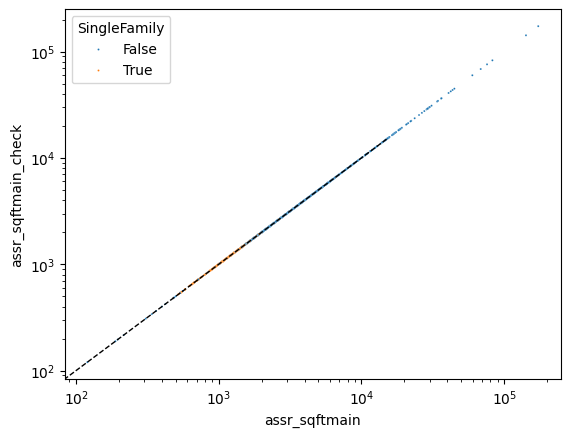

In [26]:
sns.scatterplot(data = df, x= 'assr_sqftmain', y = 'assr_sqftmain_check', 
s= 2, hue = df['usetype'] == 'Single Family Residence')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

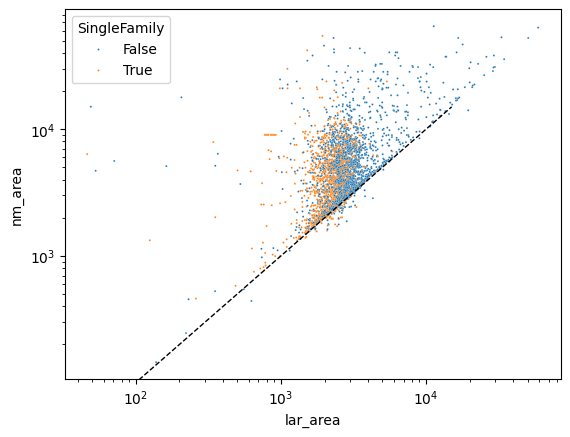

In [27]:
sns.scatterplot(data = df, x= 'lar_area', y = 'nm_area', 
s= 2, hue = df['usetype'] == 'Single Family Residence')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

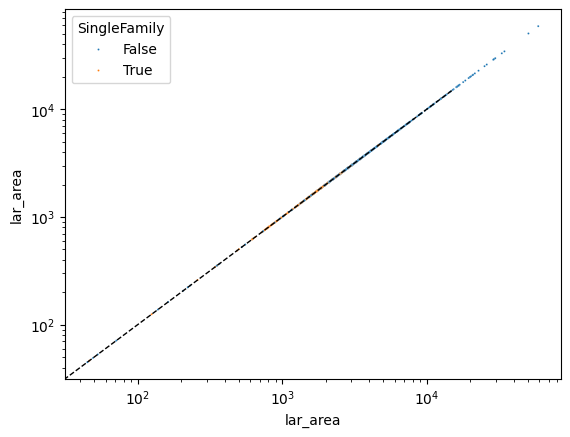

In [28]:
sns.scatterplot(data = df, x= 'lar_area', y = 'lar_area', 
s= 2, hue = df['usetype'] == 'Single Family Residence')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

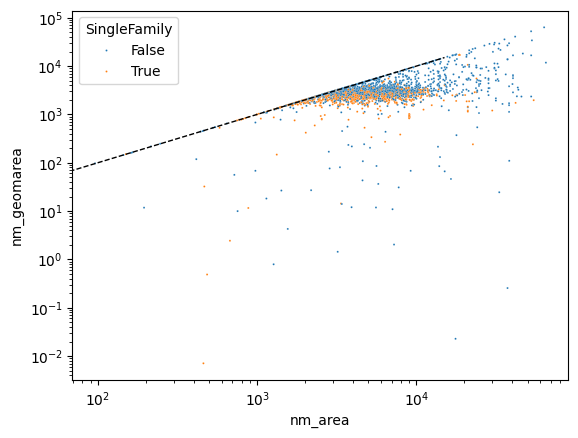

In [29]:
sns.scatterplot(data = df, x= 'nm_area', y = 'nm_geomarea', 
s= 2, hue = df['usetype'] == 'Single Family Residence')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

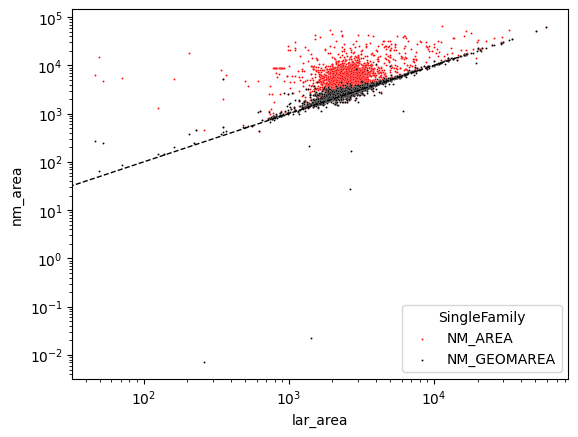

In [38]:
sns.scatterplot(data = df, x= 'lar_area', y = 'nm_area', 
s= 2, color = 'red', label = 'NM_AREA')#df['usetype'] == 'Single Family Residence')

sns.scatterplot(data = df, x= 'lar_area', y = 'nm_geomarea', 
s= 2, color = 'k',label = 'NM_GEOMAREA')# hue = df['usetype'] == 'Single Family Residence')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

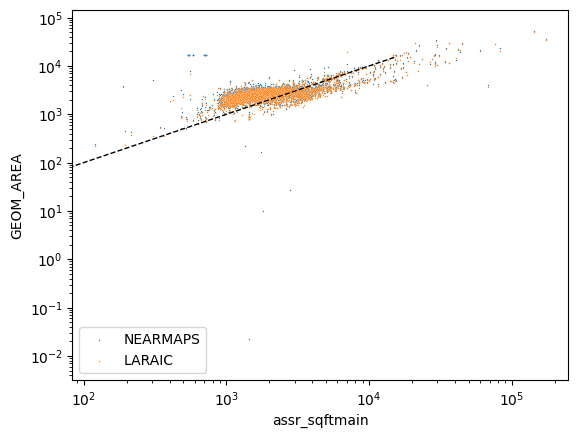

In [31]:
sns.scatterplot(data = df, 
            x= 'assr_sqftmain', y = 'nm_geomarea', label = 'NEARMAPS', s = 1)
sns.scatterplot(data = df, 
            x= 'assr_sqftmain', y = 'lar_area', label = 'LARAIC', s= 1)

plt.xscale('log'), plt.yscale('log'), plt.ylabel('GEOM_AREA')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

Text(0.5, 0, 'area metric')

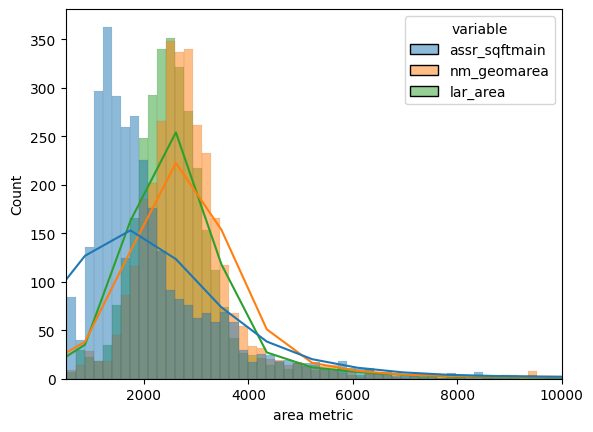

In [32]:
Z = df[['assr_sqftmain','nm_geomarea','lar_area']].melt()

sns.histplot(data = Z, x = 'value', hue = 'variable', kde = True, bins = 1000, palette= 'tab10')

plt.xlim((500,10_000))
plt.xlabel('area metric')

Text(0.5, 1.0, 'Singel Family Only')

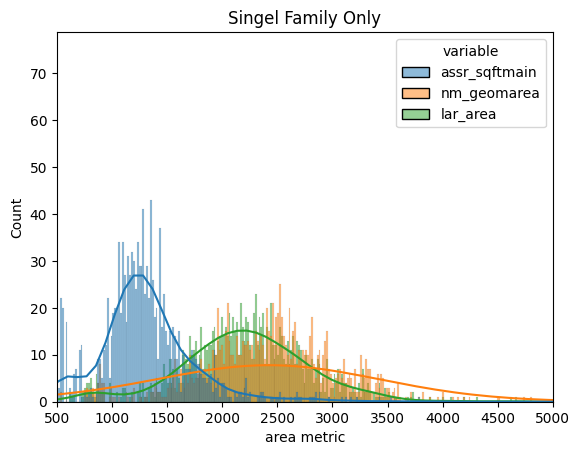

In [33]:
Z = df.query('usetype == "Single Family Residence"')[['assr_sqftmain','nm_geomarea','lar_area']].melt()

sns.histplot(data = Z, x = 'value', hue = 'variable', kde = True, bins = 1000, palette= 'tab10')

plt.xlim((500,5_000))
plt.xlabel('area metric')
plt.title('Singel Family Only')

In [46]:
# fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/2023_assessor_parcel_data.csv'
# fp='/Users/adamswietek/Documents/PostDoc/data/raw_la/parcels/Assessor_Parcels_Data_-_2006_thru_2021_output.csv'
fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/2022_all_parcel_data.csv'

df = pd.read_csv(fp)#, nrows = 1).columns

/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_21223/2950229478.py:5: DtypeWarning: Columns (6,38,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)#, nrows = 1).columns


In [48]:
dup_ids = df.groupby('AssessorID').size()
dup_ids = dup_ids[dup_ids == 2].index.tolist()
print(len(dup_ids))
df[df['AssessorID'].isin(dup_ids[5:6])]

67903


,AssessorID,usetype,usecode,usecodedescchar1,usecodedescchar2,sqftmain,case_number,situszip,taxratearea_city,ain,...,book,page,parcel,eng_dist,cncl_dist,lst_modf_dt,crtn_dt,user_id,shape_length,shape_area
478,2004-018-006,SFR,0101,Residential,Single Family Residence,2190.0,NaN,91304-2213,LOS ANGELES,2.004018e+09,...,2004.0,18.0,6.0,V,12,NaN,2/8/1993 0:00:00,NaN,114.70072,682.56641
479,2004-018-006,SFR,0101,Residential,Single Family Residence,2190.0,NaN,91304-2213,LOS ANGELES,2.004018e+09,...,2004.0,18.0,6.0,V,12,NaN,2/8/1993 0:00:00,NaN,475.98795,11461.45900


In [50]:
dups = df[df['AssessorID'].isin(dup_ids)][['AssessorID', 'sqftmain']]
same = dups.groupby('AssessorID')['sqftmain'].nunique() == 1

print("Same SQFTmain:", same.sum())
print("Different SQFTmain:", (~same).sum())

# Example of each
print("\n-- Same --")
print(dups[dups['AssessorID'].isin(same[same].index)].head(6))

print("\n-- Different --")
print(dups[dups['AssessorID'].isin(same[~same].index)].head(6))


Same SQFTmain: 67903
Different SQFTmain: 0

-- Same --
      AssessorID  sqftmain
20  2004-001-029    2423.0
21  2004-001-029    2423.0
22  2004-001-030    2298.0
23  2004-001-030    2298.0
25  2004-001-032    2226.0
26  2004-001-032    2226.0

-- Different --
Empty DataFrame
Columns: [AssessorID, sqftmain]
Index: []
